# Lotka-Volterra Models for Predator-Prey and Competitive Interactions

#### As stated on the very first day of class, one of the goals of this course is for students to understand not only the basic principles of interactions + coevolutionary theory, but to understand *how we study* interactions using a variety of methods. Many of you have asked me about how often I use coding in my research. My answer: ***All the time.***

#### In an effort to expose you to coding & evolutionary and ecological modeling, I am including two "in-class assignments" in the course, both of which will be an interactive coding notebook. This notebook focuses on Lotka-Volterra models as they relate to predator-prey and competitive interactions. I know at first this might seem scary, especially to those of you who have never seen code before. *You do not need to have any coding experience to complete this assignment*. I will walk you through how to use the notebook, and will just ask you to toggle some numbers, detail your observations, and think through those observations in the context of what we have learned in class. 

<span style="color:darkred">

**Assignment instructions:**

This assignment is worth **50 points**. Throughout the notebook you will find **22 short answer questions** that will guide you through understanding Lotka-Volterra models. Each one is worth **2 points**. I ask for a general reflection at the end that will be worth **6 points**.

You may work with a partner on this assignment, but I expect each of you to record your answers independently. So I know who worked together, please record your partner's name at the end.

</span>

<div class="alert alert-success">
<b>Learning objectives</b>
<br />1. Understand what a jupyter notebook is and how to run code in jupyter notebook cells
<br />2. Review predator-prey dynamics and Lotka-volterra modeling
<br />3. Understand how the Lotka-Volterra equations are adapted to study competition.
<br />4. Evaluate the situations that lead to competition vs. coexistence.
<div>

## First, what is a jupyter notebook?

Jupyter notebooks are interactive way of running and visualizing different coding languages (typically python) through a web-browser. They are a tool that can be use to develop and share code, and can be a really nice teaching tool as well! Here is a mini tutorial on how they work

Each block of code is contained within a **cell** which are run individually. Double click on this text, and you'll see it change. This is a Markdown cell, which allows me to make this nicely formatted text! Press shift + enter to run this cell. Below is a **code cell**, instead of text it contains code that can be run. Run the code cell below to see what happens:

In [1]:
# store value to the variable x
x = 3

# print the variable x
print(x)

3


Amazing work, you've now executed your first coding cell. Now, click into the cell and add **+ 5** after the 3. Run the cell again to see what happens. 

That's it! That's all of the "coding" you need to know to make it through this assignment :)

## Basic Lotka-Volterra Predator-Prey Model

Lotka-Volterra models help us understand ***population cyclying*** in predator & prey populations. They describe how predator-prey dynamics alone (no impact of environment) can create oscillating population cycles. Below, we will explore how the model works, and think about the ways that changing the **parameter values** alter these population cycles.

What is a **parameter**? In statistics, we refer to any variable in a model/equation as a parameter. In this case, we have "parameters" / variables that represent something real about the biology of our predator-prey system. Below, I set up a basic Lotka-Volterra model and ask you to vary these parameters and observe what happens to the cycles.

### Lotka–Volterra Predator–Prey Model

The dynamics of prey and predator populations are described by the following system of differential equations:

$$
\begin{aligned}
\frac{dN}{dt} &= \alpha N - \beta N P \\
\frac{dP}{dt} &= \delta N P - \gamma P
\end{aligned}
$$

where:

- $N(t)$ is the prey population size  
- $P(t)$ is the predator population size  
- $\alpha$ is the intrinsic growth rate of the prey  
- $\beta$ is the predation rate coefficient  
- $\gamma$ is the predator mortality rate  
- $\delta$ is the efficiency with which prey are converted into predator offspring  


We need to start by importing the python libraries that will allow us to build and visualize our models. Click into the cell below and run it. (Remember, you can run a cell by hitting shift + return at the same time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Awesome, now we're ready to begin. Below, I have two cells. The top one defines the values of the **parameters** in our model. I will be asking you to click into this cell to toggle the parameter value to see how they affect the model.

The second cell runs the model and does the plotting. So what you'll do is: run the parameter cell THEN the model/plotting cell sequentially. Everyime you change the parameter values, you'll need to re-run both of these cells to update the model.

Start by running them both without changing anything.

In [2]:
# ==========================================================
# MODEL PARAMETERS ( this is what you will edit and re-run)
# ==========================================================

alpha = 1.0     # prey intrinsic growth rate, starting value = 1.0
beta  = 0.1     # predation rate, starting value = 0.1
gamma = 1.5     # predator mortality rate, starting value = 1.5
delta = 0.1     # predator conversion efficiency, starting value = 0.5

prey0     = 10   # initial prey population, starting value = 10
predator0 = 5   # initial predator population, starting value = 5
    
#K = 50         # carrying capacity

t_max = 50      # total simulation time in generations, starting value = 50
n_points = 500  # resolution of time series

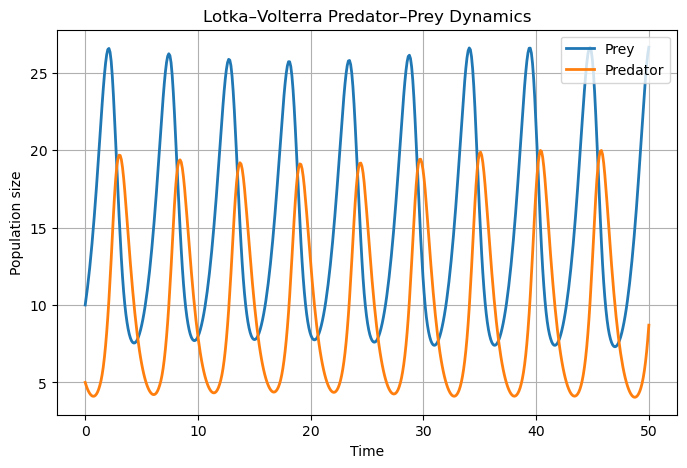

In [3]:
def lotka_volterra(t, y):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpred_dt = delta * prey * predator - gamma * predator
    return [dprey_dt, dpred_dt]

t_eval = np.linspace(0, t_max, n_points)

sol = solve_ivp(
    lotka_volterra,
    (0, t_max),
    [prey0, predator0],
    t_eval=t_eval
)

prey, predator = sol.y

plt.figure(figsize=(8, 5))
plt.plot(t_eval, prey, label="Prey", lw=2)
plt.plot(t_eval, predator, label="Predator", lw=2)
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Lotka–Volterra Predator–Prey Dynamics")
plt.legend()
plt.grid(True)

plt.show()

#### Now, follow the instructions and answer the following questions:

*Note: the way to answer the questions is by clicking into the "Answer" cells and typing your answers*.

**Question 1: Describe the dynamics of the Lotka-volterra model with the parameters I've set initially. Why do you see oscillations?**


Answer: 

**Question 2: Now play around with the parameter values. Try at least three new combinations and record your observations (tell me exactly the combinations you input, feel free to copy-paste). Try to explain why each of the new values causes the changes that you're seeing.**

Answer:

**Question 3: Try making the starting predator population really large. What happens to the prey? Now, try making the predator mortality rate really high. What happens to the pedator population? What about prey? Does this seem weird to you, given what you know about biology?**

Answer:

## Lotka-Volterra Model with Extinctions

As you probably noticed above, in a basic Lotka-Volterra model, it is *impossible* to actually get either predator or prey population to go extinct. This is because of how the math works. The population sizes can get ***REALLY*** small, but they will never reach zero. This is not biologically accurate, though. So let's explicitly incorporate the possibility of extinction into our model...

Basically all I do is force the population to go extinct if the total population size dips below 1. So I say, less than 1 individual = no more population!

In [8]:
# ==========================================================
# MODEL PARAMETERS ( this is what you will edit and re-run)
# ==========================================================

alpha = 1.0     # prey intrinsic growth rate, starting value = 1.0
beta  = 0.1     # predation rate, starting value = 0.1
gamma = 1.5     # predator mortality rate, starting value = 1.5
delta = 0.1     # predator conversion efficiency, starting value = 0.5

prey0     = 10   # initial prey population, starting value = 10
predator0 = 5   # initial predator population, starting value = 5
    
#K = 50         # carrying capacity

t_max = 50      # total simulation time in generations, starting value = 50
n_points = 500  # resolution of time series

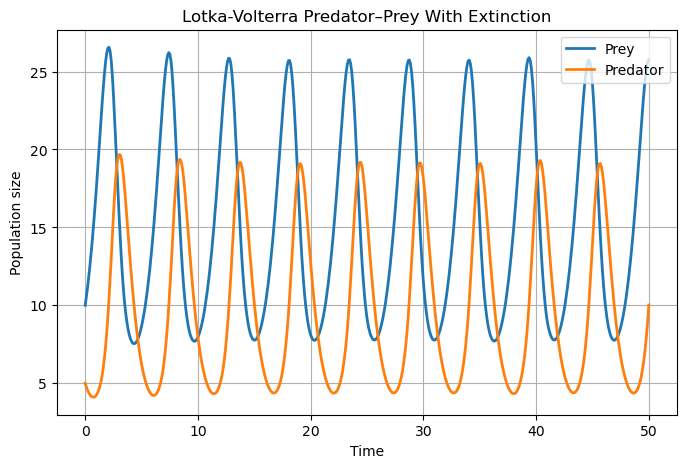

In [19]:
def lotka_volterra_extinction(t, y):
    prey, predator = y

    # Extinction threshold: if < 1, extinct forever
    if prey < 1 and predator < 1:
        return [0, 0]
    if prey < 1:
        return [0, -gamma * predator]
    if predator < 1:
        return [alpha * prey, 0]

    dprey_dt = alpha * prey - beta * prey * predator
    dpred_dt = delta * prey * predator - gamma * predator
    return [dprey_dt, dpred_dt]



t_eval = np.linspace(0, t_max, n_points)

model = lotka_volterra_extinction

sol = solve_ivp(
    model,
    (0, t_max),
    [prey0, predator0],
    t_eval=t_eval
)

prey, predator = sol.y

plt.figure(figsize=(8, 5))
plt.plot(t_eval, prey, label="Prey", lw=2)
plt.plot(t_eval, predator, label="Predator", lw=2)
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Lotka-Volterra Predator–Prey With Extinction")
plt.legend()
plt.grid(True)
plt.show()

**Question 4: Now try to make both populations go extinct, which combination of parameter values lead to extinction (in either population)? Give me at least 3.**

Answer:

**Question 5: What do you notice about the parameter values that lead to extinction? Why do you think they cause extinction?**

Answer:

**Question 6: What do you notice about the relationship between predator and prey extinctions, is this relationship symmetrical? Why or why not?**

Answer:

## One more realistic addition: carrying capacity

We discussed in lecture how carrying capacity is relevant to the competition Lokta-Volterra models, but we didn't discuss carrying capacity in the context of predator-prey. 

The reality is, prey populations will also be limited by carrying capacity, determined by the available resources in their environment (space, food, etc.). We can incorporate carrying capacity AND extinction into our predator-prey model to make it more realistic.

### Predator–Prey Model with Carrying Capacity

The dynamics of prey and predator populations are described by the following system of differential equations:

$$
\begin{aligned}
\frac{dN}{dt} &= \alpha N \left(1 - \frac{N}{K} \right) - \beta N P \\
\frac{dP}{dt} &= \delta N P - \gamma P
\end{aligned}
$$

where:

- $N(t)$ is the prey population size  
- $P(t)$ is the predator population size  

- $\alpha$ is the intrinsic growth rate of the prey  
- $K$ is the carrying capacity of the prey  
- $\beta$ is the predation rate coefficient  
- $\gamma$ is the predator mortality rate  
- $\delta$ is the efficiency with which prey are converted into predator offspring  


**Question 7: Why don't we include carrying capacity in the predator equation?**

Answer:

In [46]:
# ==========================================================
# MODEL PARAMETERS (this is what you will edit and re-run)
# ==========================================================

alpha = 1.0     # prey intrinsic growth rate, starting value = 1.0
beta  = 0.1     # predation rate, starting value = 0.1
gamma = 1.5     # predator mortality rate, starting value = 1.5
delta = 0.1     # predator conversion efficiency, starting value = 0.1

K = 50          # prey carrying capacity, starting value = 50

prey0     = 10  # initial prey population, starting value = 10
predator0 = 5   # initial predator population, starting value = 5
    
## DON'T CHANGE ##
t_max = 50      # total simulation time in generations, starting value = 50
n_points = 500  # resolution of time series

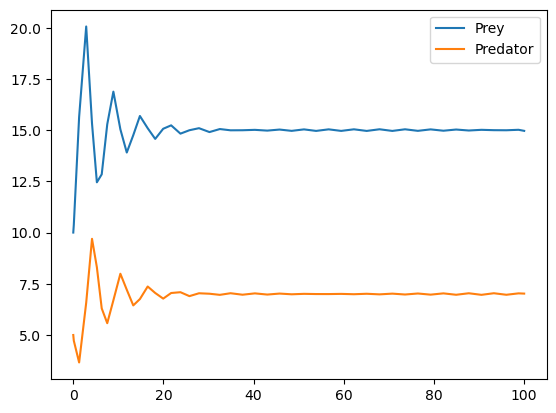

In [53]:
def predator_prey_logistic_extinction(t, y, alpha, beta, gamma, delta, K):
    prey, predator = y

    prey = max(prey, 0)
    predator = max(predator, 0)

    # Extinction threshold
    if prey < 1 and predator < 1:
        return [0, 0]

    if prey < 1:
        return [0, -gamma * predator]

    if predator < 1:
        return [alpha * prey * (1 - prey / K), 0]

    dprey_dt = alpha * prey * (1 - prey / K) - beta * prey * predator
    dpred_dt = delta * prey * predator - gamma * predator

    return [dprey_dt, dpred_dt]

sol = solve_ivp(
    predator_prey_logistic_extinction,
    t_span=(0, 100),
    y0=[prey0, predator0],
    args=(alpha, beta, gamma, delta, K),
    dense_output=True
)

plt.plot(sol.t, sol.y[0], label="Prey")
plt.plot(sol.t, sol.y[1], label="Predator")
plt.legend()

**Question 8: With the initial parameter values, what do you notice? How does this model behave differently from the original Lotka-Volterra model?**

Answer:

**Question 9: play around with the parameter values to try to get the model to behave like the original oscillating model. Can you do it? using which values? Explain why this make sense biologically.**

Answer:

## Lotka-Volterra and Competition

Okay, now let's adapt our Lotka-Volterra equations to model interspecific competition. Let's start with the models that we covered in lecture.

### Lotka–Volterra Interspecific Competition Model

The dynamics of two competing species are described by:

$$
\begin{aligned}
\frac{dN_1}{dt} &= r_1 N_1 \left( 1 - \frac{N_1 + \alpha_{12} N_2}{K_1} \right) \\
\frac{dN_2}{dt} &= r_2 N_2 \left( 1 - \frac{N_2 + \alpha_{21} N_1}{K_2} \right)
\end{aligned}
$$

where:

- $N_1(t)$ and $N_2(t)$ are population sizes  
- $r_1$, $r_2$ are intrinsic growth rates  
- $K_1$, $K_2$ are carrying capacities  
- $\alpha_{12}$ is the effect of Species 2 on Species 1  
- $\alpha_{21}$ is the effect of Species 1 on Species 2


In [115]:
# ==========================================================
# MODEL PARAMETERS (edit and re-run)
# ==========================================================

r1 = 1.0          # growth rate species 1, initial value = 1.0
r2 = 1.0          # growth rate species 2, initial value = 1.0

K1 = 50           # carrying capacity species 1, initial value = 50
K2 = 50           # carrying capacity species 2, initial value = 50

alpha12 = 0.5     # effect of species 2 on species 1, initial value = 0.5
alpha21 = 0.5     # effect of species 1 on species 2, initial value = 0.5

N1_0 = 10         # initial population species 1, initial value = 10
N2_0 = 12         # initial population species 2, initial value = 12

## DON'T CHANGE ##
t_max = 50
n_points = 500

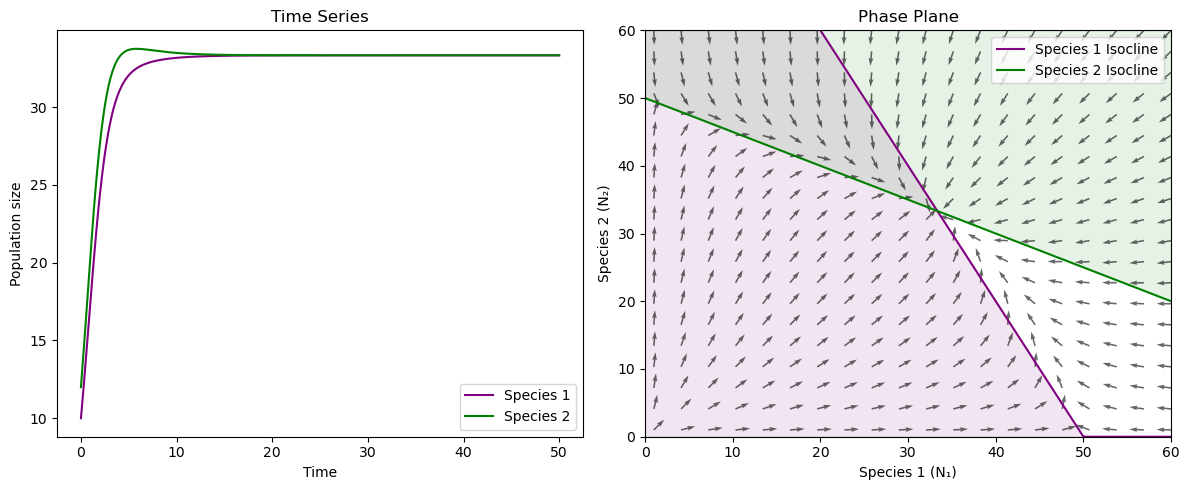

In [116]:
def lv_competition(t, y, r1, r2, K1, K2, alpha12, alpha21):
    N1, N2 = y

    dN1_dt = r1 * N1 * (1 - (N1 + alpha12 * N2) / K1)
    dN2_dt = r2 * N2 * (1 - (N2 + alpha21 * N1) / K2)

    return [dN1_dt, dN2_dt]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


## RUN MODEL ##
sol = solve_ivp(
    lv_competition,
    t_span=(0, t_max),
    y0=[N1_0, N2_0],
    t_eval=t_eval,
    args=(r1, r2, K1, K2, alpha12, alpha21),
    rtol=1e-9,
    atol=1e-9
)

plt.close('all')   # ✅ Prevent ghost figures

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------
# TIME SERIES
# -------------------
axes[0].plot(sol.t, sol.y[0], label="Species 1", color="purple")
axes[0].plot(sol.t, sol.y[1], label="Species 2", color="green")

axes[0].set_xlabel("Time")
axes[0].set_ylabel("Population size")
axes[0].legend()
axes[0].set_title("Time Series")

# -------------------
# PHASE PLANE
# -------------------

# Grid for arrows
N1 = np.linspace(1, K1 * 1.2, 20)
N2 = np.linspace(1, K2 * 1.2, 20)

N1_grid, N2_grid = np.meshgrid(N1, N2)

dN1 = r1 * N1_grid * (1 - (N1_grid + alpha12 * N2_grid) / K1)
dN2 = r2 * N2_grid * (1 - (N2_grid + alpha21 * N1_grid) / K2)

magnitude = np.sqrt(dN1**2 + dN2**2)
magnitude[magnitude == 0] = 1   # ✅ Avoid divide-by-zero

dN1_norm = dN1 / magnitude
dN2_norm = dN2 / magnitude

# Isoclines
N1_vals = np.linspace(0, K1 * 1.2, 400)

N2_iso1 = np.maximum((K1 - N1_vals) / alpha12, 0)
N2_iso2 = np.maximum(K2 - alpha21 * N1_vals, 0)

# Shading
axes[1].fill_between(N1_vals, 0, N2_iso1, alpha=0.1, color="purple")
axes[1].fill_between(N1_vals, N2_iso2, K2 * 1.2, alpha=0.1, color="green")

# Isoclines
axes[1].plot(N1_vals, N2_iso1, label="Species 1 Isocline", color="purple")
axes[1].plot(N1_vals, N2_iso2, label="Species 2 Isocline", color="green")

# ✅ Arrows ONLY
axes[1].quiver(N1_grid, N2_grid, dN1_norm, dN2_norm, alpha=0.6)

axes[1].set_xlim(0, K1 * 1.2)
axes[1].set_ylim(0, K2 * 1.2)

axes[1].set_xlabel("Species 1 (N₁)")
axes[1].set_ylabel("Species 2 (N₂)")
axes[1].legend()
axes[1].set_title("Phase Plane")

plt.tight_layout()
plt.show()

Here, I am showing you two plots. One is the "Time Series" which shows population size change over time (in generations). The second is the phase diagram with isoclines, just like the ones that we looked at in lecture.

Remember, an isocline is a line showing where population growth = 0. For a species, this means that it's where births = deaths, thus the population neither increases nor decreases. Our isoclines tell us which combination of species adundances halt growth of the populations. 
Here, I've plotted on the vector field arrows, showing you which direction the population will trend on either side of the isocline to help you visualize the population dynamics and long term outcomes.

**Question 10: Based on the initial parameter values I set, what is the outcome of competition? Remember, possible outcomes are: Extinction of competitor 1 (competitive exclusion), extinction of competitor 2 (competitive exclusion), unstable equilibrium, and stable equlibrium (coexistence).**

Answer:

**Question 11: Look at the time series. What is happening to population growth in this initial scenario. Does that make sense to you? Explain what's happening in your own words.**

Answer:

**Question 12: Now increase alpha12 to 2.0, what happens to species 1 isocline? Now put it back and do the same for alpha21, what happens to species 2's isocline? What about the population growth in each case? Which outcome of competition does each diagram represent?**

Answer:

**Question 13: Choose one of the scenarios you induced above and keep the alpha values constant. Look at time-series...which species wins out? Change some of the other parameter values, does the species that wins ever change?**

Answer:

**Question 14: Now try to induce an unstable eqilibrium, can you do it? With what parameter values? What is the relationship of carrying capacity to the alpha values in this case?**

Answer:

**Question 15: Once you've induced unstable equlibrium, keep the alpha values constant and play around with the other parameters, paying attention to the time series plot. Does the species that wins out change, or is it always the same? Which parameter values did you try and what was the outcome?**

Answer:

**Question 16: Go a little crazy with the parameter values and see what happens. See how often you can induce stable equilibrium, paying attention to the parameter values (specifically the alpha values). Does coexistence *require* weak competition? If not, what does it require?**

Answer:

## Lotka-Volterra Competition with Evolution

As we discussed in nature, alpha values themselves are dependent on *selection*. Can we model this? Sure!

We can allow the alpha values to change based on the way that competition-related traits interact within the two species. Below I show you the math for how this might work, if you're a mathy person. But the only part you really need to focus on is the very bottom, where I give you the "Biological Interpretation".

Note: above, we allowed alpha values to be assymetric (*i.e.*, species 1 could suffer more from competition than species 2). Here, because we've increased the complexity of the model we are keeping competition strength symmetric. 

### Lotka–Volterra Competition Model with Selection

We extend the classic interspecific competition model by allowing traits to evolve under selection.

Population dynamics:

$$
\begin{aligned}
\frac{dN_1}{dt} &= r_1 N_1 \left( 1 - \frac{N_1 + \alpha_{12}(z_1, z_2)\, N_2}{K_1} \right) \\
\frac{dN_2}{dt} &= r_2 N_2 \left( 1 - \frac{N_2 + \alpha_{21}(z_1, z_2)\, N_1}{K_2} \right)
\end{aligned}
$$

Trait dynamics:

$$
\begin{aligned}
\frac{dz_1}{dt} &= s \, \frac{(z_1 - z_2)}{\sigma^2} \, \alpha_{12}(z_1, z_2) \\
\frac{dz_2}{dt} &= s \, \frac{(z_2 - z_1)}{\sigma^2} \, \alpha_{21}(z_1, z_2)
\end{aligned}
$$

Competition strength depends on trait similarity:

$$
\alpha_{ij}(z_i, z_j) = 
\exp\left(-\frac{(z_i - z_j)^2}{2\sigma^2}\right)
$$

where:

- $N_1(t)$, $N_2(t)$ are population sizes  
- $z_1(t)$, $z_2(t)$ are evolving trait values  

- $r_1$, $r_2$ are intrinsic growth rates  
- $K_1$, $K_2$ are carrying capacities  
- $\alpha_{ij}$ is the competition coefficient  
- $s$ is the strength of selection  
- $\sigma$ determines how strongly trait differences reduce competition  

---

**Biological Interpretation**

- Species compete more strongly when traits are similar  
- Selection favors divergence when competition is strong  
- Trait divergence reduces niche overlap  
- Competition strength evolves dynamically  
- Evolution can stabilize coexistence


In [125]:
# ==========================================================
# MODEL PARAMETERS (edit and re-run)
# ==========================================================

# -------------------
# Population parameters
# -------------------
r1 = 1.0          # growth rate species 1, starting value = 1.0
r2 = 1.0          # growth rate species 2, starting value = 1.0

#because our alphas are symmetric, our carrying capacities will always need to be different for easy visualization
K1 = 50           # carrying capacity species 1, starting value = 50
K2 = 100           # carrying capacity species 2, starting value = 100

# -------------------
# Selection parameters
# -------------------
s = 0.1          # strength of selection, starting value = 0.1
sigma = 1.0       # niche width / competition sensitivity, starting value = 1.0

# -------------------
# Initial populations
# -------------------
N1_0 = 10
N2_0 = 12

# -------------------
# Initial trait values
# -------------------
z1_0 = 0.0        # trait species 1, starting value = 0.0
z2_0 = 0.01       # trait species 2, starting value = 0.01 (initial trait values very similar -> high competition)

## DON'T CHANGE ##
t_max = 50
n_points = 500

Final competition strength:
alpha: 0.045
Trait difference: 2.493


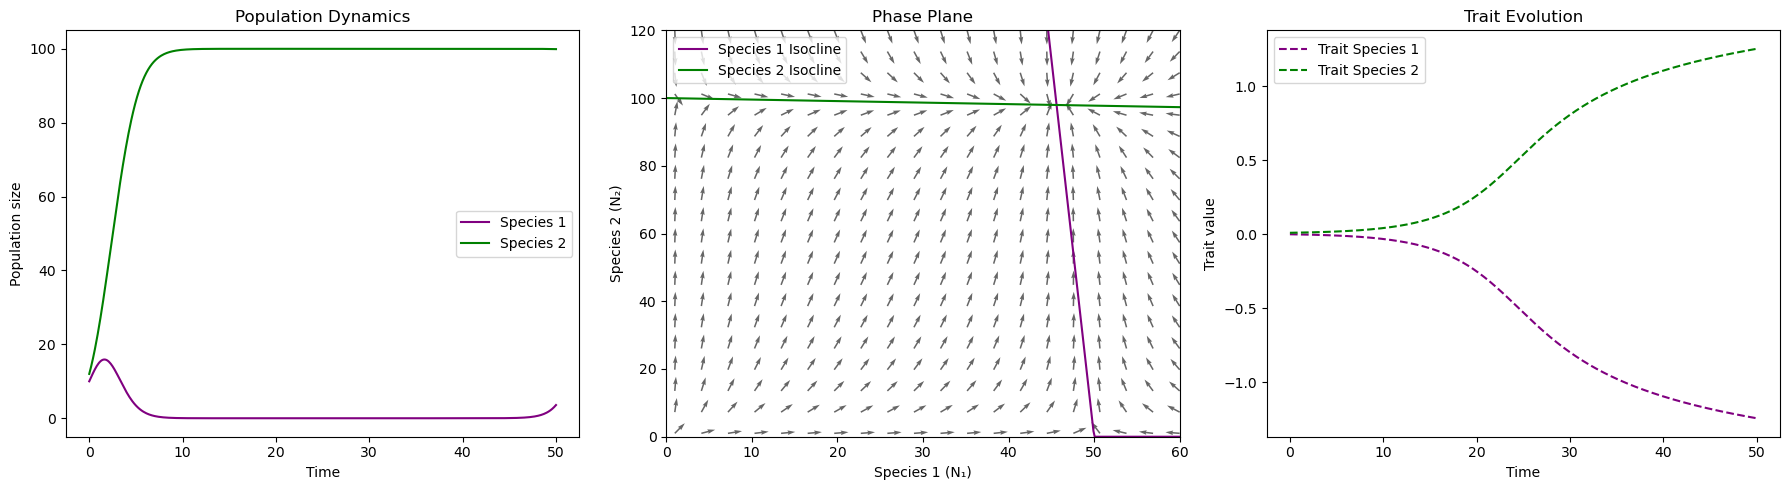

In [126]:
plt.close('all')

def lv_competition_selection(t, y, r1, r2, K1, K2, s, sigma):

    N1, N2, z1, z2 = y

    # Trait-dependent competition
    alpha12 = np.exp(-((z1 - z2)**2) / (2 * sigma**2))
    alpha21 = np.exp(-((z2 - z1)**2) / (2 * sigma**2))

    # Population dynamics
    dN1_dt = r1 * N1 * (1 - (N1 + alpha12 * N2) / K1)
    dN2_dt = r2 * N2 * (1 - (N2 + alpha21 * N1) / K2)

    # ✅ Improved selection gradient
    dz1_dt = s * (z1 - z2) * alpha12 / (sigma**2)
    dz2_dt = s * (z2 - z1) * alpha21 / (sigma**2)

    return [dN1_dt, dN2_dt, dz1_dt, dz2_dt]


# Solve system
t_eval = np.linspace(0, t_max, n_points)

sol = solve_ivp(
    lv_competition_selection,
    t_span=(0, t_max),
    y0=[N1_0, N2_0, z1_0, z2_0],
    t_eval=t_eval,
    args=(r1, r2, K1, K2, s, sigma),
    rtol=1e-9,
    atol=1e-9
)

# ----------------------------------------------------------
# FINAL TRAITS → determine competition strength
# ----------------------------------------------------------

z1_final = sol.y[2][-1]
z2_final = sol.y[3][-1]

alpha12_final = np.exp(-((z1_final - z2_final)**2) / (2 * sigma**2))
alpha21_final = np.exp(-((z2_final - z1_final)**2) / (2 * sigma**2))

print(f"Final competition strength:")
print(f"alpha: {alpha12_final:.3f}")
print(f"Trait difference: {abs(z1_final - z2_final):.3f}")

# ----------------------------------------------------------
# PLOTS
# ----------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------
# POPULATION DYNAMICS
# -------------------
axes[0].plot(sol.t, sol.y[0], color="purple", label="Species 1")
axes[0].plot(sol.t, sol.y[1], color="green", label="Species 2")

axes[0].set_xlabel("Time")
axes[0].set_ylabel("Population size")
axes[0].legend()
axes[0].set_title("Population Dynamics")

# -------------------
# PHASE PLANE
# -------------------
N1 = np.linspace(1, K1 * 1.2, 20)
N2 = np.linspace(1, K2 * 1.2, 20)

N1_grid, N2_grid = np.meshgrid(N1, N2)

dN1 = r1 * N1_grid * (1 - (N1_grid + alpha12_final * N2_grid) / K1)
dN2 = r2 * N2_grid * (1 - (N2_grid + alpha21_final * N1_grid) / K2)

mag = np.sqrt(dN1**2 + dN2**2)
mag[mag == 0] = 1

axes[1].quiver(N1_grid, N2_grid, dN1 / mag, dN2 / mag, alpha=0.6)

N1_vals = np.linspace(0, K1 * 1.2, 400)

N2_iso1 = np.maximum((K1 - N1_vals) / alpha12_final, 0)
N2_iso2 = np.maximum(K2 - alpha21_final * N1_vals, 0)

axes[1].plot(N1_vals, N2_iso1, color="purple", label="Species 1 Isocline")
axes[1].plot(N1_vals, N2_iso2, color="green", label="Species 2 Isocline")

axes[1].set_xlim(0, K1 * 1.2)
axes[1].set_ylim(0, K2 * 1.2)

axes[1].set_xlabel("Species 1 (N₁)")
axes[1].set_ylabel("Species 2 (N₂)")
axes[1].legend()
axes[1].set_title("Phase Plane")

# -------------------
# TRAIT EVOLUTION
# -------------------
axes[2].plot(sol.t, sol.y[2], color="purple", linestyle="--", label="Trait Species 1")
axes[2].plot(sol.t, sol.y[3], color="green", linestyle="--", label="Trait Species 2")

axes[2].set_xlabel("Time")
axes[2].set_ylabel("Trait value")
axes[2].legend()
axes[2].set_title("Trait Evolution")

plt.tight_layout()
plt.show()

Notice I now have a third plot showing the change in a trait value over time (we can think of this simply as the change in the trait). 

**Question 17: Look at the trait evolution plot. What is happening to the traits over the generations? How do they change with respect to each other? What biological phenomenon are we observing?**

Answer:

**Question 18: Now let's try to understand how adding evolution impacts the outcomes of competition. Let's start by going back to the simpler model...turn off evolution (make selection = 0). What happens? What outcome is this?**

Answer:

**Question 19: Now slowly increase selection. What happens?**

Answer:

**Question 20: Now change the starting trait values to be really different from one another. What do you observe? What if you vary selection with these new values?**

Answer:

**Question 21: Can evolution convert exclusion into coexistence? Under what circumstances?**

Answer:

**Question 22: Now just have some fun. Spend some time changing parameter values, and record your observations below. Does the model behavior make sense in terms of what you understand about the biology of competetive interactions? Does it confuse you?**

Answer:

## General reflection

**Use this space to reflect on this assignment. Did you find it useful to get hands-on experience with eco-evolutionary models? What parts were hard or confusing? What questions do you stil have about predator-prey dynamics and interspecific competition? What was it like to work with the code? Write a ~1 paragraph reflection (6 pts).**

Answer:

## Assignment Submission

If you worked with a partner, please record their name here.

**My partner:**

<div class="alert alert-success">
<b>Submitting the assignment</b>
<br /> When you are finished with a notebook and ready to submit it, download as an HTML version of the notebook to submit. To do this, go to the 'File Menu', then 'Download as', and select HTML. Upload the HTML notebook to the 'In-class Assignment 1' assignment in the In-class assigbments part of the Courseworks to submit your assignment. These will be due Friday, February 20th by 11:59pm.
<div>